In [ ]:
import os
import pathlib
import datetime

import xdem

import numpy as np
import numpy.ma as ma
import geoutils as gu
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

import geomulticorr as gmc

from geomulticorr.corrections import (
    CorrectionPipeline, FilterPipeline, make_corrections,
    OutlierFilter, CCFilter, StableAreaMask,
    SlopeMask, ShadowMask, SnowMask, CloudMask,
    MedianCentering, RampCorrection, TopoCorrection, SlopeRampCorrection,
)

---
## 1. Calling data

In [4]:
session = gmc.open_gmc_session(target_directory_path=pathlib.Path('/home/cusicand/03_Data/GMC_projects/MultiSensor'),
                               epsg_code=2154)

[ GeoMultiCorr ✓ ] : GMC project structure found


[ GeoMultiCorr 🚀 ] : Session 'MultiSensor' initialized.


In [5]:
# Get the forward pair
pairs = session.get_pairs()
pair = [p for p in pairs if p.pa_direction == "forward"][2]
print(pair.pa_key)

MontVallon_2019-08-03-planetscope_2020-08-26-planetscope


In [6]:
# Load displacement and CC rasters
xDisp = gu.Raster(str(pair.pa_ew_path))
yDisp = gu.Raster(str(pair.pa_ns_path))
cc = gu.Raster(str(pair.pa_cc_path))
# cc    = gu.Raster("/home/cusicand/03_Data/GMC_projects/MultiSensor/raster_data_MultiSensor/MontVallon/image_correlation/MontVallon_2018-08-26-planetscope_2019-08-03-planetscope/MontVallon_2018-08-26-planetscope_2019-08-03-planetscope-F_CC .tif")   # -ncc.tif from ASP
dem_fn = pathlib.Path("/home/cusicand/03_Data/GMC_projects/MontVallon_Res-0.5_CompElev-mean_merged.tif")
outlines_fn = pathlib.Path("/home/cusicand/03_Data/GMC_projects/MontVallon_poly.gpkg")

In [7]:
outlines = gu.Vector("/home/cusicand/03_Data/GMC_projects/MontVallon_poly.gpkg")

In [8]:
dem = gu.Raster(dem_fn)

In [9]:
dem_ref = dem.reproject(xDisp, resampling="bilinear", res=3)

In [10]:
del dem

---
## 2. Mask steps

### Print `EW` and `NS` raw masked pixels

In [10]:
print("EW and NS important information:")
print(f"EW total pixels: {xDisp.width * xDisp.height}")
print(f"NS total pixels: {yDisp.width * yDisp.height}")

EW and NS important information:
EW total pixels: 1520700
NS total pixels: 1520700


In [11]:
print("EW and NS raw masked results:")
print(f"EW raw masked pixels: {xDisp.data.mask.sum()} | masked: {xDisp.data.mask.sum() / (xDisp.width * xDisp.height) * 100:.2f}%")
print(f"NS raw masked pixels: {yDisp.data.mask.sum()} | masked: {yDisp.data.mask.sum() / (yDisp.width * yDisp.height) * 100:.2f}%")

EW and NS raw masked results:
EW raw masked pixels: 236091 | masked: 15.53%
NS raw masked pixels: 236062 | masked: 15.52%


### 2.1 Create `stable area mask` based on `OutlierFilter` + `CCFilter` + `SlopeThreshold` + `MovingAreas`

### 2.1 `OutlierFilter`

Masked pixels in OutlierFilter:
EW before OutlierFilter: 236091 | after: 262485 masked: 17.26%
NS before OutlierFilter: 236062 | after: 355071 masked: 23.35%


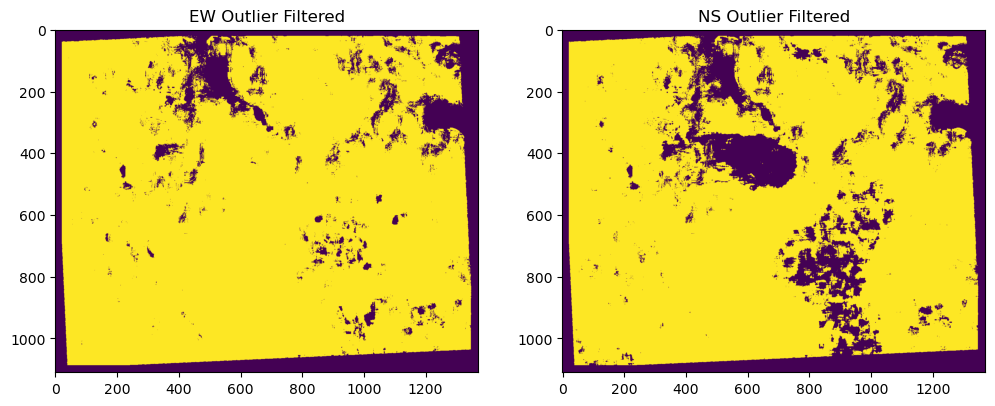

In [39]:
outlier_mask = OutlierFilter(threshold=(-10.0, 10.0))
xOF_mask, yOF_mask = (np.abs(xDisp.data) < 10).filled(False), (np.abs(yDisp.data) < 10).filled(False)
print("Masked pixels in OutlierFilter:")
print(f"EW before OutlierFilter: {xDisp.data.mask.sum()} | after: {np.sum(xOF_mask ==False)} masked: {np.sum(xOF_mask ==False) / (xDisp.width * xDisp.height) * 100:.2f}%")
print(f"NS before OutlierFilter: {yDisp.data.mask.sum()} | after: {np.sum(yOF_mask ==False)} masked: {np.sum(yOF_mask ==False) / (yDisp.width * yDisp.height) * 100:.2f}%")
fig_OF, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(xOF_mask)
ax[0].set_title("EW Outlier Filtered")
ax[1].imshow(yOF_mask)
ax[1].set_title("NS Outlier Filtered")
plt.show()

### 2.2 `CCFilter`

In [ ]:
CC_mask = (cc.data > 0.5).filled(False)

Masked pixels in CCFilter:
Before CCFilter: 236091 | after: 324615 masked: 21.35%


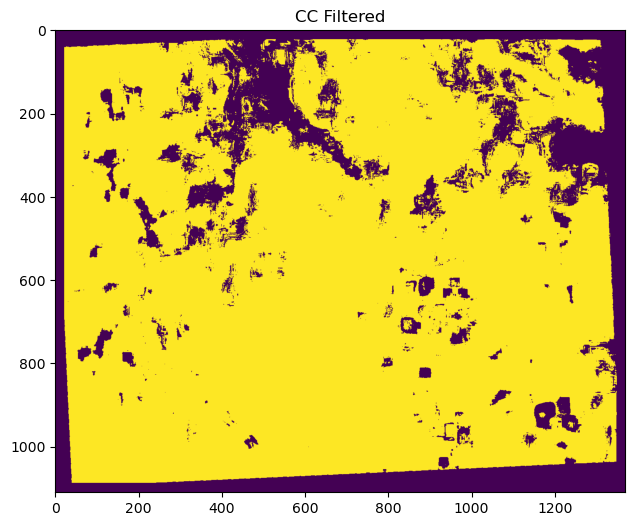

In [65]:
print("Masked pixels in CCFilter:")
print(f"Before CCFilter: {xDisp.data.mask.sum()} | after: {np.sum(CC_mask ==False)} masked: {np.sum(CC_mask == False) / (xDisp.width * xDisp.height) * 100:.2f}%")
fig_CC, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.imshow(CC_mask)
ax.set_title("CC Filtered")
plt.show()

### 2.3 `StableAreaMask` = `SlopeThreshold` + `MovingAras`

### 2.3.1 `SlopeMask`

`SlopeMask(min_slope=5, max_slope=40)` keeps only pixels on moderate slopes.
The flat hilltop and the steep flanks should both be masked.

In [63]:
slope = xdem.terrain.slope(dem_ref)
slope_mask = (slope.data < 40).filled(False)
del slope

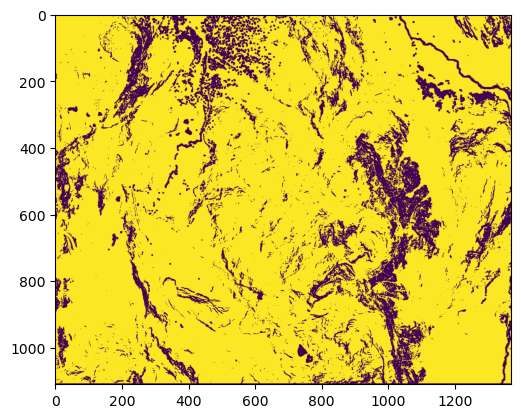

In [64]:
plt.imshow(slope_mask)

### 2.3.2 Moving Areas

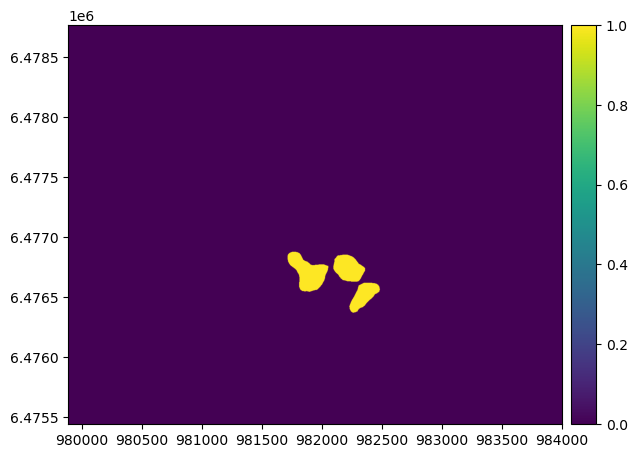

In [70]:
rg_mask = outlines.create_mask(dem_ref)
rg_mask.data.filled(False)
rg_mask.plot()

### 2.3.3 Merging all masks into singe one

Final inlier mask results:
EW inlier pixels: 998057 | masked: 34.37%
NS inlier pixels: 927047 | masked: 39.04%


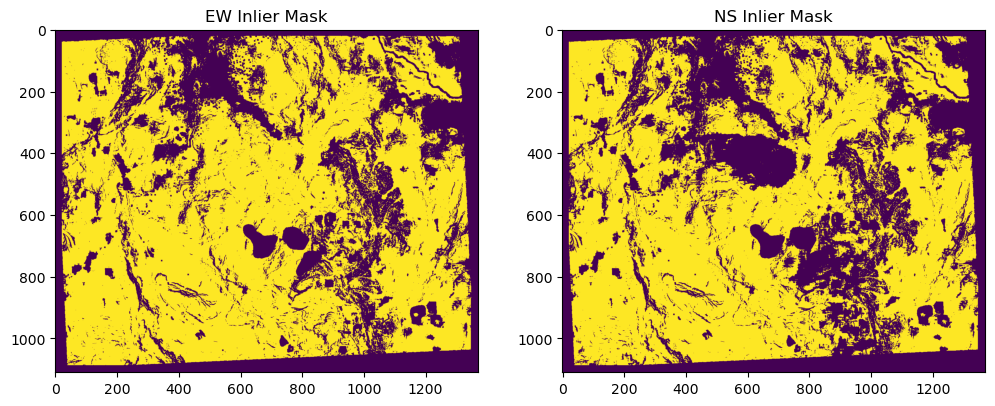

In [74]:
xDisp_inlier_mask = xOF_mask & CC_mask & slope_mask & ~rg_mask.data
yDisp_inlier_mask = yOF_mask & CC_mask & slope_mask & ~rg_mask.data
print("Final inlier mask results:")
print(f"EW inlier pixels: {np.sum(xDisp_inlier_mask)} | masked: {np.sum(xDisp_inlier_mask == False) / (xDisp.width * xDisp.height) * 100:.2f}%")
print(f"NS inlier pixels: {np.sum(yDisp_inlier_mask)} | masked: {np.sum(yDisp_inlier_mask == False) / (yDisp.width * yDisp.height) * 100:.2f}%")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(xDisp_inlier_mask)
ax[0].set_title("EW Inlier Mask")
ax[1].imshow(yDisp_inlier_mask)
ax[1].set_title("NS Inlier Mask")
plt.show()

In [79]:
xDisp_mask, yDisp_mask = xDisp.copy(), yDisp.copy()
xDisp_mask.set_mask(~xDisp_inlier_mask)
yDisp_mask.set_mask(~yDisp_inlier_mask)

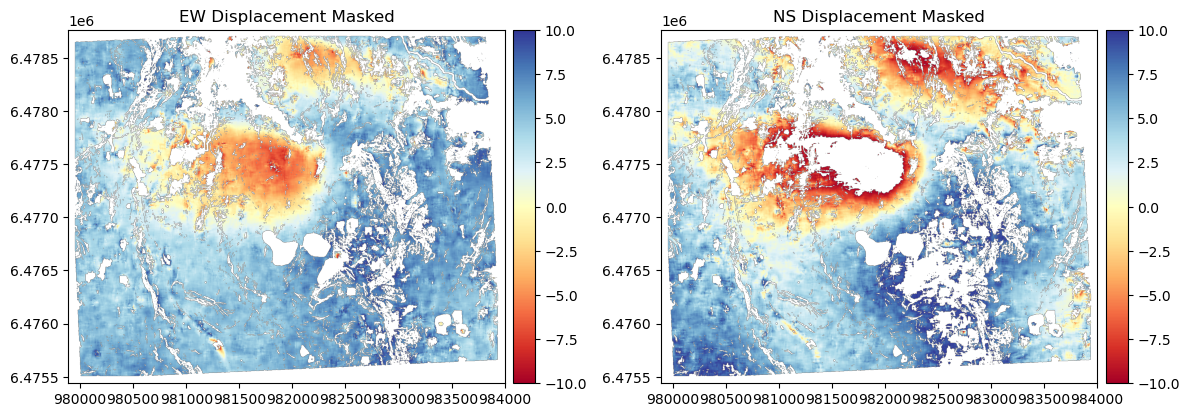

In [84]:
vmax=10
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
xDisp_mask.plot(ax=axs[0], cmap='RdYlBu', vmin=-vmax, vmax=vmax)
axs[0].set_title("EW Displacement Masked")
yDisp_mask.plot(ax=axs[1], cmap='RdYlBu', vmin=-vmax, vmax=vmax)
axs[1].set_title("NS Displacement Masked")
plt.show()


In [109]:
xDisp_orig = xDisp[xDisp_inlier_mask]
xDisp_nstable_orig, xDisp_mean_orig = len(xDisp_orig), np.mean(xDisp_orig)
xDisp_med_orig, xDisp_nmad_orig = np.median(xDisp_orig), xdem.spatialstats.nmad(xDisp_orig)

yDisp_orig = yDisp[yDisp_inlier_mask]
yDisp_nstable_orig, yDisp_mean_orig = len(yDisp_orig), np.mean(yDisp_orig)
yDisp_med_orig, yDisp_nmad_orig = np.median(yDisp_orig), xdem.spatialstats.nmad(yDisp_orig)

print(f"Number of stable pixels: {xDisp_nstable_orig}")
print(f"xDIsp and yDisp before correction:\
      \n\tMean xDisp: {xDisp_mean_orig:.2f} | Mean yDisp: {yDisp_mean_orig:.2f}\
      \n\tMedian xDisp: {xDisp_med_orig:.2f} | Median yDisp: {yDisp_med_orig:.2f}\
      \n\tNMAD xDisp: {xDisp_nmad_orig:.2f} | NMAD yDisp: {yDisp_nmad_orig:.2f}")

xDisp_corrected = xDisp - xDisp_med_orig
yDisp_corrected = yDisp - yDisp_med_orig

print(f"Number of stable pixels: {xDisp_nstable_orig}")
print(f"xDIsp and yDisp after correction:\
      \n\tMean xDisp: {np.mean(xDisp_corrected):.2f} | Mean yDisp: {np.mean(yDisp_corrected):.2f}\
      \n\tMedian xDisp: {np.median(xDisp_corrected):.2f} | Median yDisp: {np.median(yDisp_corrected):.2f}\
      \n\tNMAD xDisp: {xdem.spatialstats.nmad(xDisp_corrected):.2f} | NMAD yDisp: {xdem.spatialstats.nmad(yDisp_corrected):.2f}")

/home/cusicand/miniconda3/envs/gmc_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_32870/3095542868.py:3: DeprecationWarning: Call to deprecated function 'nmad'. Xdem.spatialstats.nmad is being deprecated in favor of geoutils.stats.nmad. This functionality will be removed in version 0.4.
  xDisp_med_orig, xDisp_nmad_orig = np.median(xDisp_orig), xdem.spatialstats.nmad(xDisp_orig)
/tmp/ipykernel_32870/3095542868.py:7: DeprecationWarning: Call to deprecated function 'nmad'. Xdem.spatialstats.nmad is being deprecated in favor of geoutils.stats.nmad. This functionality will be removed in version 0.4.
  yDisp_med_orig, yDisp_nmad_orig = np.median(yDisp_orig), xdem.spatialstats.nmad(yDisp_orig)
/home/cusicand/miniconda3/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to t

Number of stable pixels: 998057
xDIsp and yDisp before correction:      
	Mean xDisp: 3.78 | Mean yDisp: 2.42      
	Median xDisp: 4.70 | Median yDisp: 3.18      
	NMAD xDisp: 2.31 | NMAD yDisp: 3.84
Number of stable pixels: 998057


/tmp/ipykernel_32870/3095542868.py:22: DeprecationWarning: Call to deprecated function 'nmad'. Xdem.spatialstats.nmad is being deprecated in favor of geoutils.stats.nmad. This functionality will be removed in version 0.4.
  \n\tNMAD xDisp: {xdem.spatialstats.nmad(xDisp_corrected):.2f} | NMAD yDisp: {xdem.spatialstats.nmad(yDisp_corrected):.2f}")


xDIsp and yDisp after correction:      
	Mean xDisp: -0.62 | Mean yDisp: -0.78      
	Median xDisp: 0.15 | Median yDisp: 0.15      
	NMAD xDisp: 2.49 | NMAD yDisp: 4.68


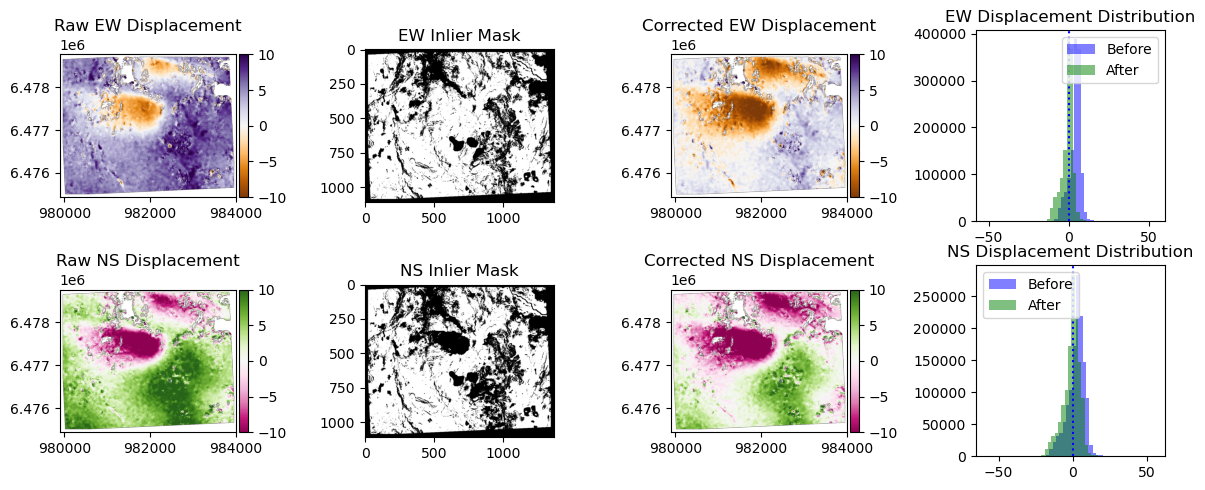

In [114]:
fig, axs = plt.subplot_mosaic([['a)', 'b)', 'c)', 'd)'],
                               ['e)', 'f)', 'g)', 'h)']],
                              figsize=(12, 5))
vmax=10
xDisp.plot(ax=axs['a)'], cmap='PuOr', vmin=-vmax, vmax=vmax)
axs['a)'].set_title("Raw EW Displacement")
axs['b)'].imshow(xDisp_inlier_mask, cmap='gray')
axs['b)'].set_title("EW Inlier Mask")
xDisp_corrected.plot(ax=axs['c)'], cmap='PuOr', vmin=-vmax, vmax=vmax)
axs['c)'].set_title("Corrected EW Displacement")
axs['d)'].hist(xDisp.data[~xDisp.data.mask].flatten(), bins=50, color='blue', alpha=0.5, label='Before')
axs['d)'].hist(xDisp_corrected.data[~xDisp_corrected.data.mask].flatten(), bins=50, color='green', alpha=0.5, label='After')
axs['d)'].axvline(0, color='blue', linestyle=':')
axs['d)'].set_title("EW Displacement Distribution")
axs['d)'].legend()

yDisp.plot(ax=axs['e)'], cmap='PiYG', vmin=-vmax, vmax=vmax)
axs['e)'].set_title("Raw NS Displacement")
axs['f)'].imshow(yDisp_inlier_mask, cmap='gray')
axs['f)'].set_title("NS Inlier Mask")
yDisp_corrected.plot(ax=axs['g)'], cmap='PiYG', vmin=-vmax, vmax=vmax)
axs['g)'].set_title("Corrected NS Displacement")
axs['h)'].hist(yDisp.data[~yDisp.data.mask].flatten(), bins=50, color='blue', alpha=0.5, label='Before')
axs['h)'].hist(yDisp_corrected.data[~yDisp_corrected.data.mask].flatten(), bins=50, color='green', alpha=0.5, label='After')
axs['h)'].axvline(0, color='blue', linestyle=':')
axs['h)'].set_title("NS Displacement Distribution")
axs['h)'].legend()

plt.show()

### Testing RampCorrection

In [ ]:
ramp_corr = RampCorrection(lambda_reg=1e-6)
ramp_corr.fit(xDisp_corrected, stable_mask=xDisp_inlier_mask)
print(ramp_corr.meta)
xD_ramp = ramp_corr.apply(xDisp_corrected)
yD_ramp = ramp_corr.apply(yDisp_corrected)

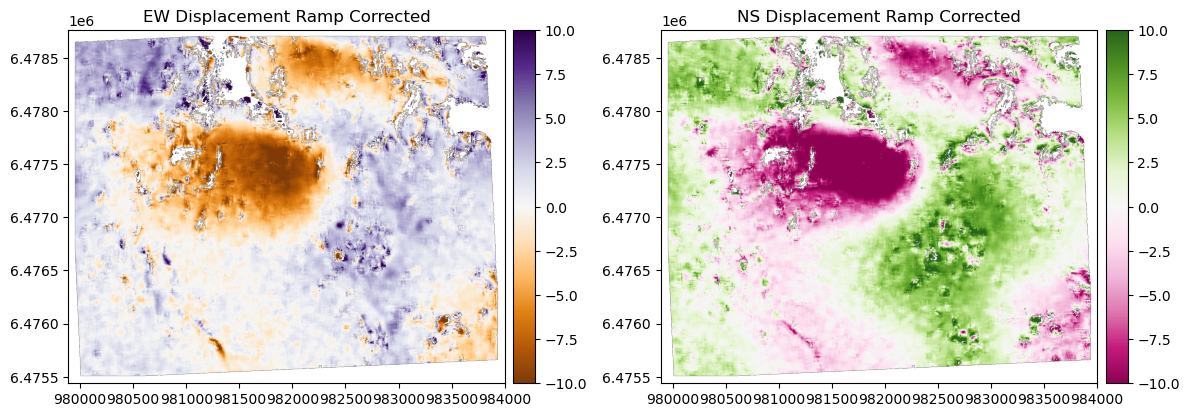

In [141]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
vmax=10
xD_ramp.plot(ax=ax[0], cmap='PuOr', vmin=-vmax, vmax=vmax)
ax[0].set_title("EW Displacement Ramp Corrected")
yD_ramp.plot(ax=ax[1], cmap='PiYG', vmin=-vmax, vmax=vmax)
ax[1].set_title("NS Displacement Ramp Corrected")
plt.show()

In [11]:
# 1. Common spatial filters (same for EW and NS)
common = CCFilter(0.6) + SlopeMask(max_slope=60) + StableAreaMask(outlines)

In [12]:
# 2. Per-component stable masks (different OutlierFilter thresholds if needed)
x_stable = common.compute(xDisp, cc=cc, dem=dem_ref) \
           & OutlierFilter((-10, 10)).generate_mask(xDisp)
y_stable = common.compute(yDisp, cc=cc, dem=dem_ref) \
           & OutlierFilter((-10, 10)).generate_mask(yDisp)

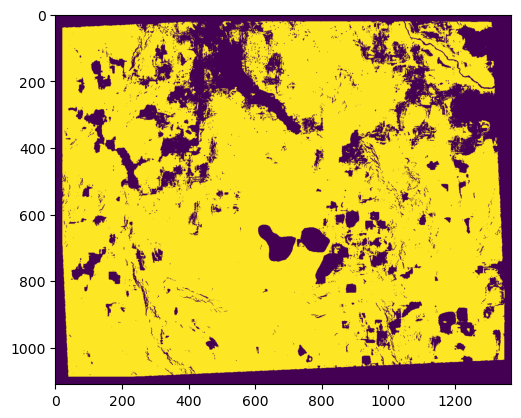

In [14]:
plt.imshow(x_stable)

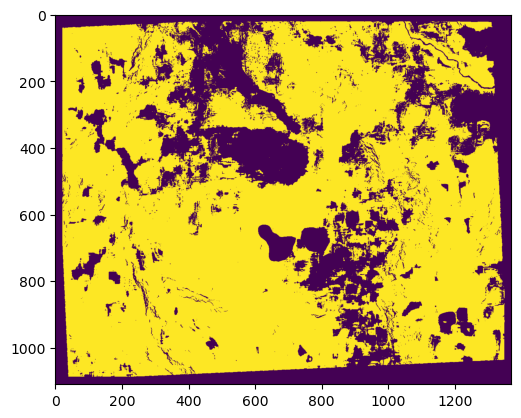

In [15]:
plt.imshow(y_stable)

In [21]:
# 3. Correction pipeline (statistics fitted on stable pixels only)
corrections = MedianCentering() + RampCorrection() + TopoCorrection(order = "quadratic")

In [22]:
corrections

CorrectionPipeline([MedianCentering -> RampCorrection -> TopoCorrection])

In [23]:
# 4. Apply independently per component
xc, yc = make_corrections(xDisp, yDisp, corrections, x_stable, y_stable, dem=dem_ref)

/home/cusicand/miniconda3/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


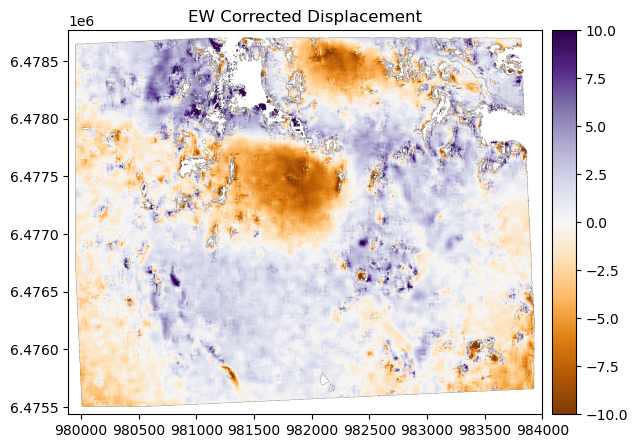

In [24]:
vmax=10
xc.plot(cmap='PuOr', vmin=-vmax, vmax=vmax)
plt.title("EW Corrected Displacement")
plt.show()

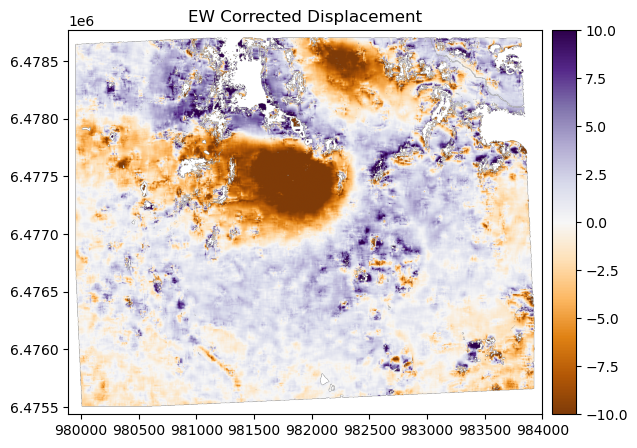

In [ ]:
vmax=10
yc.plot(cmap='PuOr', vmin=-vmax, vmax=vmax)
plt.title("NS Corrected Displacement")
plt.show()